# 01 — Synthetic Returns Data: Generation & EDA

Generate a realistic e-commerce returns dataset with three planted fraud archetypes,
then explore its statistical properties.

**Why synthetic?** No clean public returns-fraud dataset exists. Building synthetic
data with known ground truth is itself a portfolio skill — it lets us validate that
our models can detect the signals we intentionally planted.

In [1]:
import sys
import sys
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[2] / "src"))  # commerce-ml-lab/src  (shared lib)
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))  # 02_returns_intelligence/src
from pathlib import Path

sys.path.insert(0, str(Path().resolve().parents[2] / "src"))  # commerce-ml-lab/src  (shared lib)
sys.path.insert(0, str(Path().resolve().parents[0] / "src"))  # 02_returns_intelligence/src

import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from commerce_ml.data.synthetic import generate_returns_dataset, SyntheticConfig
from commerce_ml.viz.plotting import apply_style, PALETTE

apply_style()
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

customers, orders, returns = generate_returns_dataset(n_customers=20_000, random_state=42)
print(f"customers: {len(customers):,}  |  orders: {len(orders):,}  |  returns: {len(returns):,}")
print(f"Overall return rate: {orders['was_returned'].mean():.1%}")
print(f"Fraud rate in returns: {returns['is_fraud'].mean():.2%}")
print(f"\nArchetype breakdown:\n{customers['archetype'].value_counts()}")

customers: 20,000  |  orders: 70,806  |  returns: 10,476
Overall return rate: 14.8%
Fraud rate in returns: 3.86%

Archetype breakdown:
archetype
normal       19620
wardrober      160
ring           120
velocity       100
Name: count, dtype: int64


## Return rates by category and archetype

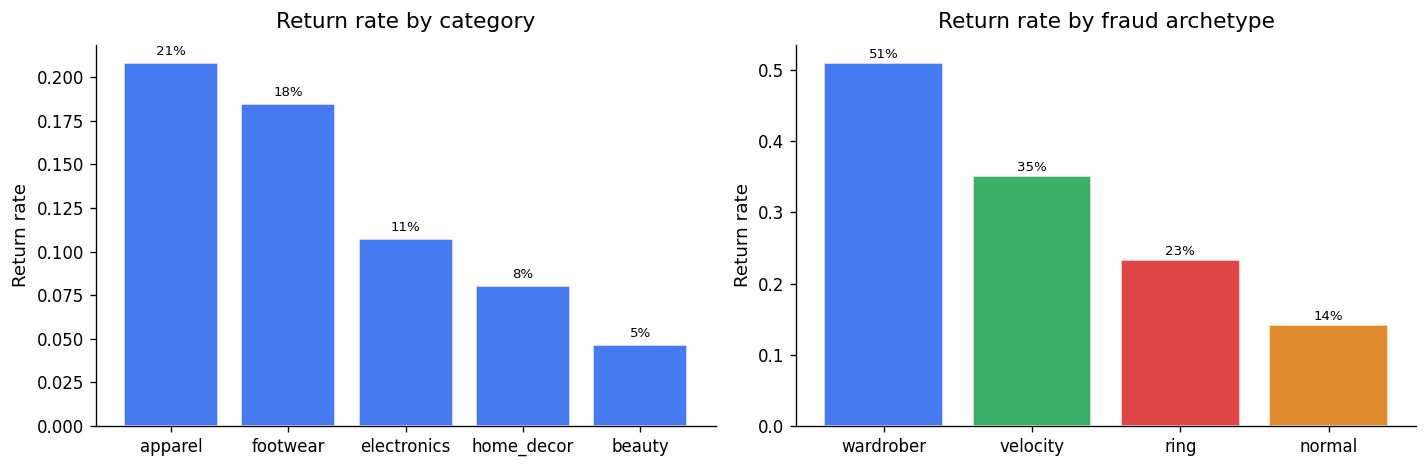

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Return rate by category
cat_rr = orders.groupby("category")["was_returned"].mean().sort_values(ascending=False)
axes[0].bar(cat_rr.index, cat_rr.values, color=PALETTE[0], alpha=0.85, edgecolor="white")
axes[0].set_ylabel("Return rate")
axes[0].set_title("Return rate by category")
for bar, val in zip(axes[0].patches, cat_rr.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.0%}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# Return rate by archetype
arch_rr = (
    orders.merge(customers[["customer_id", "archetype"]], on="customer_id")
    .groupby("archetype")["was_returned"]
    .mean()
    .sort_values(ascending=False)
)
colors = {a: c for a, c in zip(["wardrober", "velocity", "ring", "normal"], PALETTE)}
axes[1].bar(
    arch_rr.index,
    arch_rr.values,
    color=[colors.get(a, PALETTE[0]) for a in arch_rr.index],
    alpha=0.85,
    edgecolor="white",
)
axes[1].set_ylabel("Return rate")
axes[1].set_title("Return rate by fraud archetype")
for bar, val in zip(axes[1].patches, arch_rr.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{val:.0%}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig(RESULTS / "synthetic_return_rates.png", dpi=120)
plt.show()

## Fraud signal analysis: what separates fraudsters from honest customers?

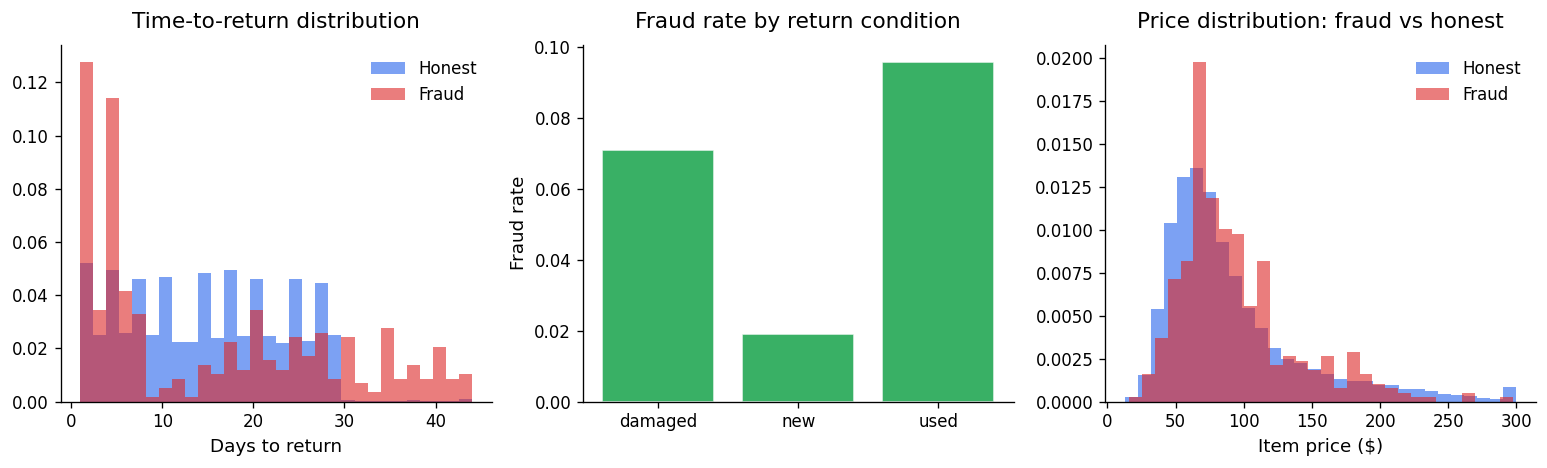

Key fraud signals planted in the data:
  Avg days to return — honest: 14.9d | fraud: 15.3d
  Used/damaged condition — honest: 25.7% | fraud: 64.1%
  Median price — honest: $76 | fraud: $82


In [3]:
merged = returns.merge(orders[["order_id", "category", "item_price"]], on="order_id").merge(
    customers[["customer_id", "archetype"]], on="customer_id"
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Days to return distribution
for label, grp, color in [
    ("Honest", merged[~merged["is_fraud"]], PALETTE[0]),
    ("Fraud", merged[merged["is_fraud"]], PALETTE[2]),
]:
    axes[0].hist(
        grp["days_to_return"].clip(upper=60),
        bins=30,
        alpha=0.6,
        color=color,
        label=label,
        density=True,
    )
axes[0].set_xlabel("Days to return")
axes[0].set_title("Time-to-return distribution")
axes[0].legend()

# Condition
cond_fraud = merged.groupby("condition")["is_fraud"].mean()
axes[1].bar(cond_fraud.index, cond_fraud.values, color=PALETTE[1], alpha=0.85, edgecolor="white")
axes[1].set_ylabel("Fraud rate")
axes[1].set_title("Fraud rate by return condition")

# Price distribution
for label, grp, color in [
    ("Honest", merged[~merged["is_fraud"]], PALETTE[0]),
    ("Fraud", merged[merged["is_fraud"]], PALETTE[2]),
]:
    axes[2].hist(
        grp["item_price"].clip(upper=300),
        bins=30,
        alpha=0.6,
        color=color,
        label=label,
        density=True,
    )
axes[2].set_xlabel("Item price ($)")
axes[2].set_title("Price distribution: fraud vs honest")
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS / "synthetic_fraud_signals.png", dpi=120)
plt.show()

print("Key fraud signals planted in the data:")
print(
    f"  Avg days to return — honest: {merged[~merged['is_fraud']]['days_to_return'].mean():.1f}d "
    f"| fraud: {merged[merged['is_fraud']]['days_to_return'].mean():.1f}d"
)
print(
    f"  Used/damaged condition — honest: {(merged[~merged['is_fraud']]['condition'] != 'new').mean():.1%} "
    f"| fraud: {(merged[merged['is_fraud']]['condition'] != 'new').mean():.1%}"
)
print(
    f"  Median price — honest: ${merged[~merged['is_fraud']]['item_price'].median():.0f} "
    f"| fraud: ${merged[merged['is_fraud']]['item_price'].median():.0f}"
)

## Address-sharing rings: graph structure

Total ring customers: 120
Shared addresses: 13 (avg 9.2 accounts per address)


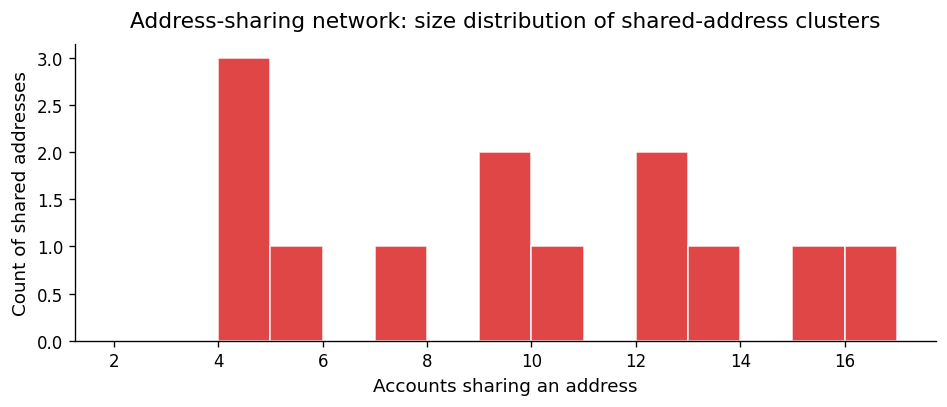

In [4]:
ring_customers = customers[customers["archetype"] == "ring"]
addr_sharing = customers.groupby("address_id")["customer_id"].count()
ring_addrs = addr_sharing[addr_sharing > 1]

print(f"Total ring customers: {len(ring_customers):,}")
print(f"Shared addresses: {len(ring_addrs):,} (avg {ring_addrs.mean():.1f} accounts per address)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(
    addr_sharing[addr_sharing > 1],
    bins=range(2, addr_sharing.max() + 2),
    color=PALETTE[2],
    alpha=0.85,
    edgecolor="white",
)
ax.set_xlabel("Accounts sharing an address")
ax.set_ylabel("Count of shared addresses")
ax.set_title("Address-sharing network: size distribution of shared-address clusters")
plt.tight_layout()
plt.savefig(RESULTS / "synthetic_ring_structure.png", dpi=120)
plt.show()

In [5]:
customers.to_parquet(RESULTS / "customers.parquet", index=False)
orders.to_parquet(RESULTS / "orders.parquet", index=False)
returns.to_parquet(RESULTS / "returns.parquet", index=False)
print("Saved customers / orders / returns to results/")

Saved customers / orders / returns to results/
